# 08 — Wells, Gauges & Observation Metadata

Calibrating a model starts with bookkeeping: *which real-world
observation well corresponds to which model hydrograph, in which layer,
at which node?* `iwfm_io` makes that bookkeeping DataFrame-first:

- **`iwfm_io.wells`** — groundwater-level (GWL) observation wells:
  metadata schema + validation, hydrograph linking, multi-layer
  compositing, mesh mapping with transmissivity weighting
- **`iwfm_io.gauges`** — the stream mirror: gauge metadata, NOUTR spec
  linking, flow/stage series extraction

Both feed directly into the PEST workflow of notebooks 09–10.

**Requires:** the sample model with Results.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("sample model not found — see notebook 01")


SAMPLE_MODEL = find_sample_model()
RESULTS_DIR = SAMPLE_MODEL / "Results"

## The `gwl_metadata` schema

One row per observation well. Core columns:

| column | meaning |
|--------|---------|
| `well_id` | unique identifier (any hashable) |
| `group` | observation group (drives PEST obs naming, notebook 09) |
| `site_code` | the key that links to model hydrograph names |
| `perf_top`, `perf_bottom` | perforation depths (ft below GSE) |
| `layer` | fixed model layer (`<NA>` = derive from perforations) |

The rule: a well has **either** a known layer **or** perforations (or
neither — then a default applies). `validate_gwl_metadata` enforces the
schema; `gwl_metadata_from_legacy` converts the classic DWR table format
(`SITE`/`HYDID`/`GRP`/`perft`/`perfb` with 0/−1 layer codes).

In [2]:
from iwfm_io import read_gw_main, validate_gwl_metadata

gw = read_gw_main(SAMPLE_MODEL / "Simulation" / "GW" / "GW_MAIN.dat")
print(f"model prints {gw.n_hydrographs} GW hydrographs")
gw.hydrographs.head(4)

model prints 42 GW hydrographs


,id,hydtyp,layer,x,y,node,name,notes
0,1,0,1,574000.0,4440000.0,<NA>,GWHyd1,
1,2,1,1,NaN,NaN,412,GWHyd2,
2,3,1,1,NaN,NaN,391,GWHyd3,
3,4,1,1,NaN,NaN,370,GWHyd4,


In [3]:
# Build metadata for six wells matching sample hydrograph sites.
# In a real project this table comes from your monitoring-well inventory.
gwl_md = pd.DataFrame({
    "well_id": ["obs_a", "obs_b", "obs_c", "obs_d", "obs_e", "obs_x"],
    "group": [10, 10, 10, 20, 20, 20],
    "site_code": ["GWHyd2", "GWHyd5", "GWHyd23", "GWHyd26", "GWHyd40",
                  "NOT_IN_MODEL"],
    "perf_top": [np.nan, 120.0, np.nan, np.nan, 80.0, np.nan],
    "perf_bottom": [np.nan, 300.0, np.nan, np.nan, 260.0, np.nan],
    "layer": pd.array([1, pd.NA, 2, 2, pd.NA, pd.NA], dtype="Int64"),
})
print("validation problems:", validate_gwl_metadata(gwl_md) or "none")
gwl_md

validation problems: none


,well_id,group,site_code,perf_top,perf_bottom,layer
0,obs_a,10,GWHyd2,NaN,NaN,1
1,obs_b,10,GWHyd5,120.0,300.0,<NA>
2,obs_c,10,GWHyd23,NaN,NaN,2
3,obs_d,20,GWHyd26,NaN,NaN,2
4,obs_e,20,GWHyd40,80.0,260.0,<NA>
5,obs_x,20,NOT_IN_MODEL,NaN,NaN,<NA>


## Link wells to model hydrographs

`link_hydrographs` matches `site_code` against the hydrograph names from
the GW main file. Models that print one site at several layers use the
`name%layer` convention (`350092N001%2`) — the stem matches the site
code and the suffix is cross-checked against the LAYER field. The sample
model prints plain single-layer names, which match as single stems.

The result reports exactly what did and didn't match — unmatched wells
and orphan model sites are the first thing to audit in a calibration.

In [4]:
from iwfm_io import link_hydrographs

link = link_hydrographs(gwl_md, gw.hydrographs)
print(link.summary())
print("unmatched wells:", link.unmatched_wells)
link.links

{'n_wells_linked': 5, 'n_hydrographs_linked': 5, 'n_unmatched_wells': 1, 'n_orphan_stems': 37, 'n_layer_mismatches': 0}
unmatched wells: ['obs_x']


,well_id,hyd_id,layer,x,y,stem
0,obs_a,2,1,NaN,NaN,GWHyd2
1,obs_b,5,1,NaN,NaN,GWHyd5
2,obs_c,23,2,NaN,NaN,GWHyd23
3,obs_d,26,2,NaN,NaN,GWHyd26
4,obs_e,40,2,NaN,NaN,GWHyd40


## Extract well time series from model output

`composite_well_hydrographs` pulls each well's series out of the
hydrograph output and — when a well spans several layers — combines them
with per-layer fractions. Fractions come from a DataFrame or from a
`WellMapping` (below).

In [5]:
from iwfm_io import composite_well_hydrographs, read_hydrograph_hdf

hyd_out = read_hydrograph_hdf(RESULTS_DIR / "GWHyd.hdf")

# single-layer wells: fraction 1.0 in their linked layer
fractions = link.links[["well_id", "layer"]].assign(fraction=1.0)
well_series = composite_well_hydrographs(link, hyd_out, fractions)
well_series.head(3)

well_id,obs_a,obs_b,obs_c,obs_d,obs_e
datetime,,,,,
1990-10-01,280.000,280.000,290.000,290.000,290.000
1990-10-02,281.676,280.745,282.851,281.712,275.041
1990-10-03,283.330,281.471,283.123,281.051,271.280


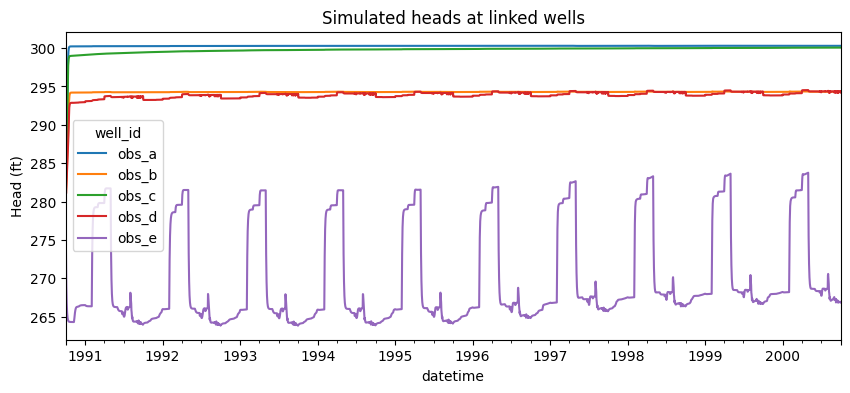

In [6]:
import matplotlib.pyplot as plt

ax = well_series.plot(figsize=(10, 4), title="Simulated heads at linked wells")
ax.set_ylabel("Head (ft)")
plt.show()

## Sequence numbers within groups

The DWR convention names observations `<group><seq>` (e.g. well 3 of
group 67 → `670003`, see `GroupSequenceScheme` in notebook 09).
`assign_sequences` fills a `seq` column — spatially ordered, and it
**never renumbers** wells that already have one (the ledger property:
adding wells later keeps every existing name stable).

In [7]:
from iwfm_io import assign_sequences

seq_md = assign_sequences(gwl_md, link, order="north_to_south")
seq_md[["well_id", "group", "seq"]]

group 10: 3 well(s) without coordinates appended in well_id order


group 20: 3 well(s) without coordinates appended in well_id order


,well_id,group,seq
0,obs_a,10,1
1,obs_b,10,2
2,obs_c,10,3
3,obs_d,20,1
4,obs_e,20,2
5,obs_x,20,3


## Enrich metadata from the model

`enrich_gwl_metadata` adds model context (nearest node's GSE, subregion)
and observation coverage (`n_obs`, first/last date) — the table you
filter when deciding which wells enter the calibration.

In [8]:
from iwfm_io import enrich_gwl_metadata, open_model

model = open_model(SAMPLE_MODEL)

# synthetic observation records for the demo (yours come from field data)
rng = np.random.default_rng(7)
obs = pd.concat([
    pd.DataFrame({
        "site": w,
        "datetime": pd.date_range("1992-01-15", periods=60, freq="ME"),
        "value": 250 + rng.normal(0, 2, 60),
    }) for w in ["obs_a", "obs_b", "obs_d"]
], ignore_index=True)

enriched = enrich_gwl_metadata(model, gwl_md, link=link, obs=obs)
enriched[["well_id", "gse", "subregion", "n_obs", "first_date", "last_date"]]

,well_id,gse,subregion,n_obs,first_date,last_date
0,obs_a,NaN,NaN,60,1992-01-31,1996-12-31
1,obs_b,NaN,NaN,60,1992-01-31,1996-12-31
2,obs_c,NaN,NaN,0,NaT,NaT
3,obs_d,NaN,NaN,60,1992-01-31,1996-12-31
4,obs_e,NaN,NaN,0,NaT,NaT
5,obs_x,NaN,NaN,0,NaT,NaT


## Mapping wells onto the mesh: `build_well_mapping`

For wells that are *not* at hydrograph print sites — or whose screen
spans several layers — `build_well_mapping` places each well on the FE
mesh and computes per-(node, layer) weights:

1. explicit `layer` → weight 1.0 on that layer
2. else perforation interval ∩ stratigraphy, weighted by
   **transmissivity** (thickness × Kh when `kh=` is given, thickness
   alone otherwise)
3. else a default layer (with warnings for intervals that miss every
   aquifer or lie below the model)

Spatially: nearest node, or `spatial="idw"` to spread over k neighbors.

In [9]:
from iwfm_io import build_well_mapping

nodes = model.nodes_df()
wells = pd.DataFrame({
    "well_id": ["deep_1", "shallow_1", "span_1"],
    "x": nodes["x"].iloc[[60, 200, 350]].values,
    "y": nodes["y"].iloc[[60, 200, 350]].values,
    "perf_top": [np.nan, 30.0, 60.0],
    "perf_bottom": [np.nan, 120.0, 400.0],
    "layer": pd.array([2, pd.NA, pd.NA], dtype="Int64"),
})
mapping = build_well_mapping(model, wells)
mapping.wells

,well_id,x,y,node,method
0,deep_1,586000.0,4404000.0,61,layer
1,shallow_1,572000.0,4418000.0,201,perforation
2,span_1,578000.0,4432000.0,351,perforation


In [10]:
# per-(well, node, layer) weights — sum to 1 per well
mapping.weights

,well_id,node,layer,weight
0,deep_1,61,2,1.0
1,shallow_1,201,1,1.0
2,span_1,351,1,1.0


In [11]:
# One matrix multiply composites simulated heads at the wells.
# Any heads source works: {layer: frame}, node_N_layer_M columns, or a
# model exposing heads_df(layer) — here the adapter itself.
composited = mapping.composite(model)
composited.iloc[[0, -1]]

well_id,deep_1,shallow_1,span_1
datetime,,,
1990-10-01,290.0000,280.0000,280.0000
2000-10-01,496.6012,284.9794,298.1174


In [12]:
# The mapping persists to CSV, so the (potentially slow) build happens
# once and the forward run just reloads it.
import tempfile

from iwfm_io import WellMapping

mapping_csv = Path(tempfile.gettempdir()) / "well_mapping_demo.csv"
mapping.to_csv(mapping_csv)
reloaded = WellMapping.from_csv(mapping_csv)
print("round-trip OK:", np.allclose(reloaded.composite(model).values,
                                    composited.values))

round-trip OK: True


### Unknown completions: `select_best_layers`

When neither layer nor perforations are known, `select_best_layers`
tries each layer's simulated series against the well's observed record
and picks the best-RMSE layer (with a minimum-observation guard).

In [13]:
from iwfm_io import select_best_layers

unknown = pd.DataFrame({
    "well_id": ["mystery"],
    "x": [nodes["x"].iloc[220]], "y": [nodes["y"].iloc[220]],
})
m_unknown = build_well_mapping(model, unknown)

heads = {lyr: model.heads_df(layer=lyr) for lyr in (1, 2)}
# fake observed record that tracks layer 2
layer2_at_node = heads[2].iloc[:, 220]
mystery_obs = pd.DataFrame({
    "site": "mystery",
    "datetime": layer2_at_node.index[::30],
    "value": layer2_at_node.values[::30] + rng.normal(0, 0.5, len(layer2_at_node[::30])),
})
picked = select_best_layers(m_unknown, heads, mystery_obs)
print("selected layer per well:", picked.to_dict())

selected layer per well: {'mystery': 2}


---
# Stream gauges: `iwfm_io.gauges`

The stream mirror of the same workflow. Gauge metadata links to the
stream main file's NOUTR hydrograph specs by name.

In [14]:
from iwfm_io import read_stream_main
from iwfm_io.gauges import link_stream_hydrographs, validate_gauge_metadata

sm = read_stream_main(SAMPLE_MODEL / "Simulation" / "Stream" / "Stream_MAIN.dat")
print(f"{sm.config['n_hydrographs']} stream hydrograph specs, "
      f"IHSQR={sm.config['ihsqr']}")

gauge_md = pd.DataFrame({
    "gauge_id": ["usgs_11447650", "usgs_11303500", "cdec_bnd"],
    "group": [1, 1, 1],
    "site_code": ["StrmHyd_3", "StrmHyd_12", "StrmHyd_21"],
})
print("validation:", validate_gauge_metadata(gauge_md) or "clean")

glink = link_stream_hydrographs(gauge_md, sm)
print(glink.summary())
glink.links

23 stream hydrograph specs, IHSQR=2
validation: clean
{'n_gauges_linked': 3, 'n_hydrographs_linked': 3, 'n_unmatched_gauges': 0, 'n_orphan_names': 20, 'ihsqr': 2}


,gauge_id,hyd_id,node_id,name
0,usgs_11447650,3,3,StrmHyd_3
1,usgs_11303500,12,12,StrmHyd_12
2,cdec_bnd,21,21,StrmHyd_21


## Flow and stage series

The sample model prints **both** flow and stage (`IHSQR=2`): flows in
output columns 1..NOUTR, stages in NOUTR+1..2·NOUTR.
`stream_hydrograph_series` knows the block layout — just say which
quantity you want.

In [15]:
from iwfm_io import read_hydrograph_out
from iwfm_io.gauges import stream_hydrograph_series

strm_out = read_hydrograph_out(RESULTS_DIR / "StrmHyd.out")
flows = stream_hydrograph_series(glink, strm_out, quantity="flow")
stages = stream_hydrograph_series(glink, strm_out, quantity="stage")
flows.head(3)

,usgs_11447650,usgs_11303500,cdec_bnd
datetime,,,
1990-10-02,1013.23,2.33,5695.78
1990-10-03,1013.23,1.39,3536.34
1990-10-04,1013.23,0.74,2242.96


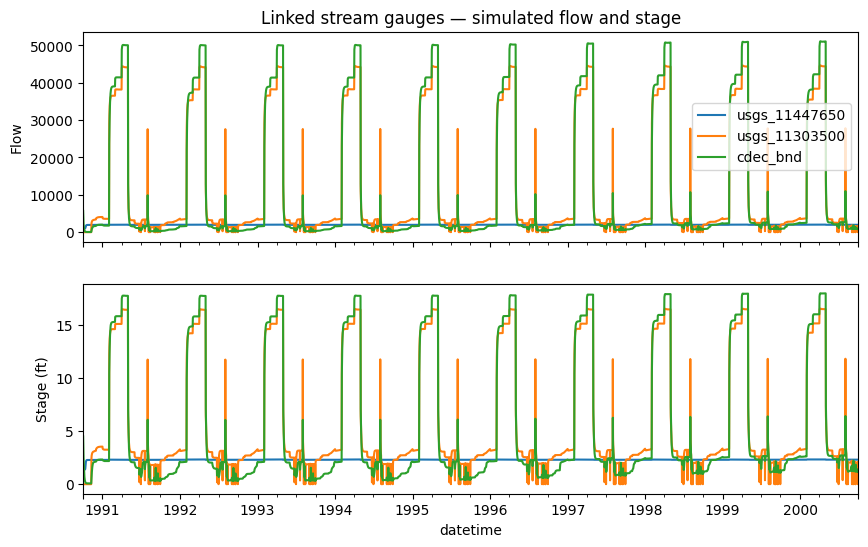

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
flows.plot(ax=axes[0], legend=True)
axes[0].set_ylabel("Flow")
stages.plot(ax=axes[1], legend=False)
axes[1].set_ylabel("Stage (ft)")
axes[0].set_title("Linked stream gauges — simulated flow and stage")
plt.show()

## Gauge sequences

Same ledger behavior as wells — ordered along the stream network
(upstream to downstream) via the linked node ids.

In [17]:
from iwfm_io.gauges import assign_gauge_sequences

assign_gauge_sequences(gauge_md, glink)[["gauge_id", "group", "seq"]]

,gauge_id,group,seq
0,usgs_11447650,1,1
1,usgs_11303500,1,2
2,cdec_bnd,1,3


## Recap

- `gwl_metadata` / `gauge_metadata` are plain DataFrames with a
  validated schema — keep them in version control
- `link_hydrographs` / `link_stream_hydrographs` connect them to the
  model and *report* every mismatch
- `composite_well_hydrographs` + `build_well_mapping` turn multi-layer
  reality into single observation series
- `stream_hydrograph_series` handles IWFM's flow/stage block layout

Notebook 09 turns these series into PEST observations; notebook 11
links gauges to CalSim channels in a DSS file.

In [18]:
mapping_csv.unlink()